# UPWARDS Summer Program
## Materials Informatics Tutorial
Trevor David Rhone

RPI

https://materials-intelligence.com/

---------------------------------------

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/quantum-intelligence/semiconductor-manufacturing-analytics/blob/main/notebooks/materials_informatics.ipynb)

## Introduction to Python

Preliminary activities:

- switch to a cpu runtime type
- install the packages below

Download 2D magnetic materials formation energies data set:
Download data from : https://archive.materialscloud.org/record/2019.0020/v1

Description of data and corresponding study can be found here: https://www.nature.com/articles/s41598-020-72811-z

save the file to your google drive (with colab) or your local drive (jupyter notebook).
Can also upload from github: https://github.com/quantum-intelligence/semiconductor-manufacturing-analytics

In [ ]:
%%capture
!pip install pandas numpy scikit-learn -q

In [4]:
print("Hello World")

Hello World


Recreate the print statement above in the below cell.  Modify it so you replace 'World' with the name of your best friend.

In [5]:
# Insert your code here:

You can do math using python!

In [6]:
a = 2
b = 2
c = a + b
print("a + b =", c)

a + b = 4


You can also create lists of items in python and manipulate the lists:

In [7]:
list1 = ['cat', 'dog', 'horse']
list2 = ['orange', 'black', 'brown']

# let's inspect the lists with a for loop:
for ith, item in enumerate(list1):
    print(ith, item)

0 cat
1 dog
2 horse


In [8]:
# Print the contents of both lists in the code block below, with the ith item in each list concatenated:


We can create a list of numbers and perform some tasks on the numbers in the list

In [ ]:
list3 = [3, 1, 4, 2]
result = []
for item in list3:
    newitem = item * 2.0
    result.append(newitem)
# print the contents of result below:



In [ ]:
# We can 'pick' certain elements out of a list given some screening criteria: 
result2 = []
for item in list3:
    if item > 2:  # <--- This is your screening criterion [implemented with an 'if else' statement]
        result2.append(item)
    else:
        print("this item does not satisfy the screening criterion : ", item)
# print the contents of result2 below:



Import some modules! Modules contain useful python functions.

For example, Numpy contains useful numerical methods.

Pandas is a useful data analysis tool.

Matplotlib and seaborn are excellent data visualization modules.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [12]:
# Create an array of numbers using numpy
x_array = np.asarray([1, 2, 3, 4])
y_array = np.random.random([1, 4])
# Print the contents of x_array and y_array

Use visualization tools (e.g. matplotlib) to plot x_array and y_array

Text(0.5, 1.0, 'this is my first plot in matplotlib!')

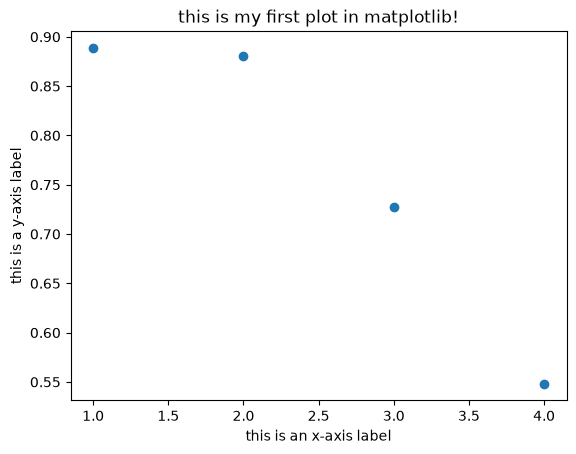

In [13]:
plt.scatter(x_array, y_array)
plt.xlabel('this is an x-axis label')
plt.ylabel('this is a y-axis label')
plt.title("this is my first plot in matplotlib!")
# modify the above code to label the x and y axis. 
# x-axis: "time"
# y-axis "amplitude"
# modify the title.

Challenge: Create some dummy data using numpy and make an interesting two-dimensional plot using seaborn

In [14]:
# insert code below:



It can be useful to create python functions to perform certain tasks:

In [15]:
def my_adder(a, b):
    """ 
    This function adds two numbers and returns the result 
    """
    c = a + b
    return c

# Test your function by calling it below and printing the result
a = 11
b = 91
c = my_adder(a, b)

In [16]:
# Create a function that takes two lists, multiplies the ith index of both lists to create a new list that is the product of the two input lists:
def multiply_items_list(listA, listB):
    """
    add your comment here
    """
    # add your code here


# test your function here:



## Data analytics on a 2D materials database

We will reproduce some of the results in the following paper:

Rhone, T.D., Chen, W., Desai, S. et al. Data-driven studies of magnetic two-dimensional materials. Sci Rep 10, 15795 (2020).

https://doi.org/10.1038/s41598-020-72811-z


### Data munging
The data set typically needs to be processed before it can be used in data analytics

Import your dataset into the work space and inspect it

In [ ]:
use_colab = False #Set this to false if you're running the jupyter noteobook locally. Set it to True if you're using Google colaboratory.
if use_colab:
    from google.colab import drive
    drive.mount('/content/drive')

In [18]:
# Create dataframe of "magneticmoment_Ef_data.csv" using pandas.
# Change the path to magneticmoment_Ef_data.csv as needed.
if use_colab:
    DATA_PATH = "drive/MyDrive/UPWARDS_Tutorial_2026/magneticmoment_Ef_data.csv"
else: 
    cwd = os.getcwd()
    DATA_PATH = os.path.join(cwd, 'data', 'magneticmoment_Ef_data.csv')

In [19]:
# load the csv file using pandas and save the result to a pandas dataframe
df = pd.read_csv(DATA_PATH)

# show the first three rows of the pandas dataframe, df:
df.head(n=3)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/trevorrhone/Documents-LOCAL/RPI/Projects/2026/UPWARDS_summer_school/notebooks/data/magneticmoment_Ef_data.csv'

In [ ]:
# print the columns
df.columns[1:-5]  # we're using pandas dataframe indexing here.  See https://pandas.pydata.org/docs/user_guide/indexing.html for more information.

# See https://www.nature.com/articles/s41598-020-72811-z for a definition of the descriptors below.

Index(['formation_energy', 'elem_frac', 'elem_list', 'energy', 'formula',
       'magnetic_moment', 'spin_index', 'num_p', 'num_d', 'num_f',
       'atomic_rad', 'atomic_vol', 'covalent_rad', 'dipole', 'eaffinity',
       'num_electrons', 'atomic_rad_sum_dif', 'atomic_rad_std_dif',
       'atomic_rad_std', 'atomic_rad_avg', 'atomic_rad_max_dif',
       'atomic_vol_sum_dif', 'atomic_vol_std_dif', 'atomic_vol_std',
       'atomic_vol_avg', 'atomic_vol_max_dif', 'covalentrad_sum_dif',
       'covalentrad_std_dif', 'covalentrad_std', 'covalentrad_avg',
       'covalentrad_max_dif', 'dipole_sum_dif', 'dipole_std_dif', 'dipole_std',
       'dipole_avg', 'dipole_max_dif', 'eaffinity_sum_dif',
       'eaffinity_std_dif', 'eaffinity_std', 'e_affinity_avg',
       'e_affinity_max_dif', 'numelectron_sum_dif', 'numelectron_std_dif',
       'numelectron_std', 'numelectron_avg', 'numelectron_max_dif',
       'vdwradius_sum_dif', 'vdwradius_std_dif', 'vdwradius_std',
       'vdwradius_avg', 'vdwradiu

In [ ]:
# You can inspect the contents of the dataframe using slicing:
df.iloc[:5,1:6] # change the numbers in the square brackets to see how it affects what's displayed below:

,formation_energy,elem_frac,elem_list,energy,formula
0,-1.152920,"[{Element Cr: 0.1}, {Element Co: 0.1}, {Elemen...","[Element Cr, Element Co, Element Ge, Element T...",-46.782036,Cr1Co1Ge1Te6P1
1,-1.325311,"[{Element Cr: 0.1}, {Element Co: 0.1}, {Elemen...","[Element Cr, Element Co, Element Ge, Element Te]",-46.171992,Cr1Co1Ge2Te6
2,-1.458288,"[{Element Cr: 0.1}, {Element Co: 0.1}, {Elemen...","[Element Cr, Element Co, Element Si, Element G...",-47.107590,Cr1Co1Si1Ge1Te6
3,-1.389637,"[{Element Cr: 0.1}, {Element Co: 0.1}, {Elemen...","[Element Cr, Element Co, Element Si, Element T...",-47.821374,Cr1Co1Si1Te6P1
4,-1.620268,"[{Element Cr: 0.1}, {Element Co: 0.1}, {Elemen...","[Element Cr, Element Co, Element Si, Element Te]",-48.072190,Cr1Co1Si2Te6


### Feature/Descriptor Selection

Let's use the 'formation_energy' as the target variable, y

and the following columns as a first guess for the features, X:

'numelectron_avg', 'nvalence_avg', 'dipole_avg', 'atomic_rad_avg', 'hardness_mean', 'covalentrad_std_dif'

How many descriptors should we choose? Which descriptors are the best descriptors?


In [ ]:
target = 'formation_energy'
y = df[target]
subset_cols = ['numelectron_avg', 'nvalence_avg', 'dipole_avg', 'atomic_rad_avg', 'hardness_mean', 'covalentrad_std_dif']
X = df[subset_cols]

# print df.shape to inspect the size of your data set.
# insert code below:


### Data Visualization
Let's make some scatter plots and histogram plots to inspect the data. Look for patterns in the data. Which descriptors are good for trying to predict the formation energy?

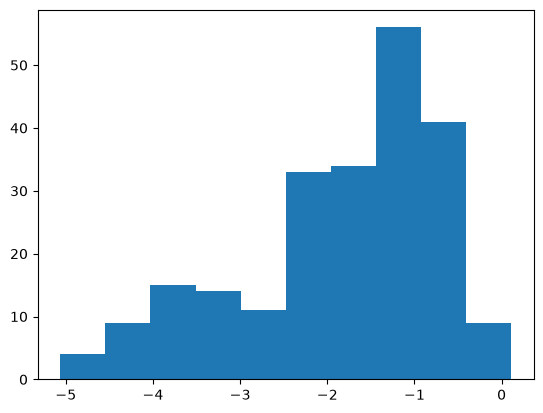

In [ ]:
plt.hist(y)
# what does plt.hist() do?
# add axis labels
# plt.xlabel("")
# plt.ylabel("")
plt.show()


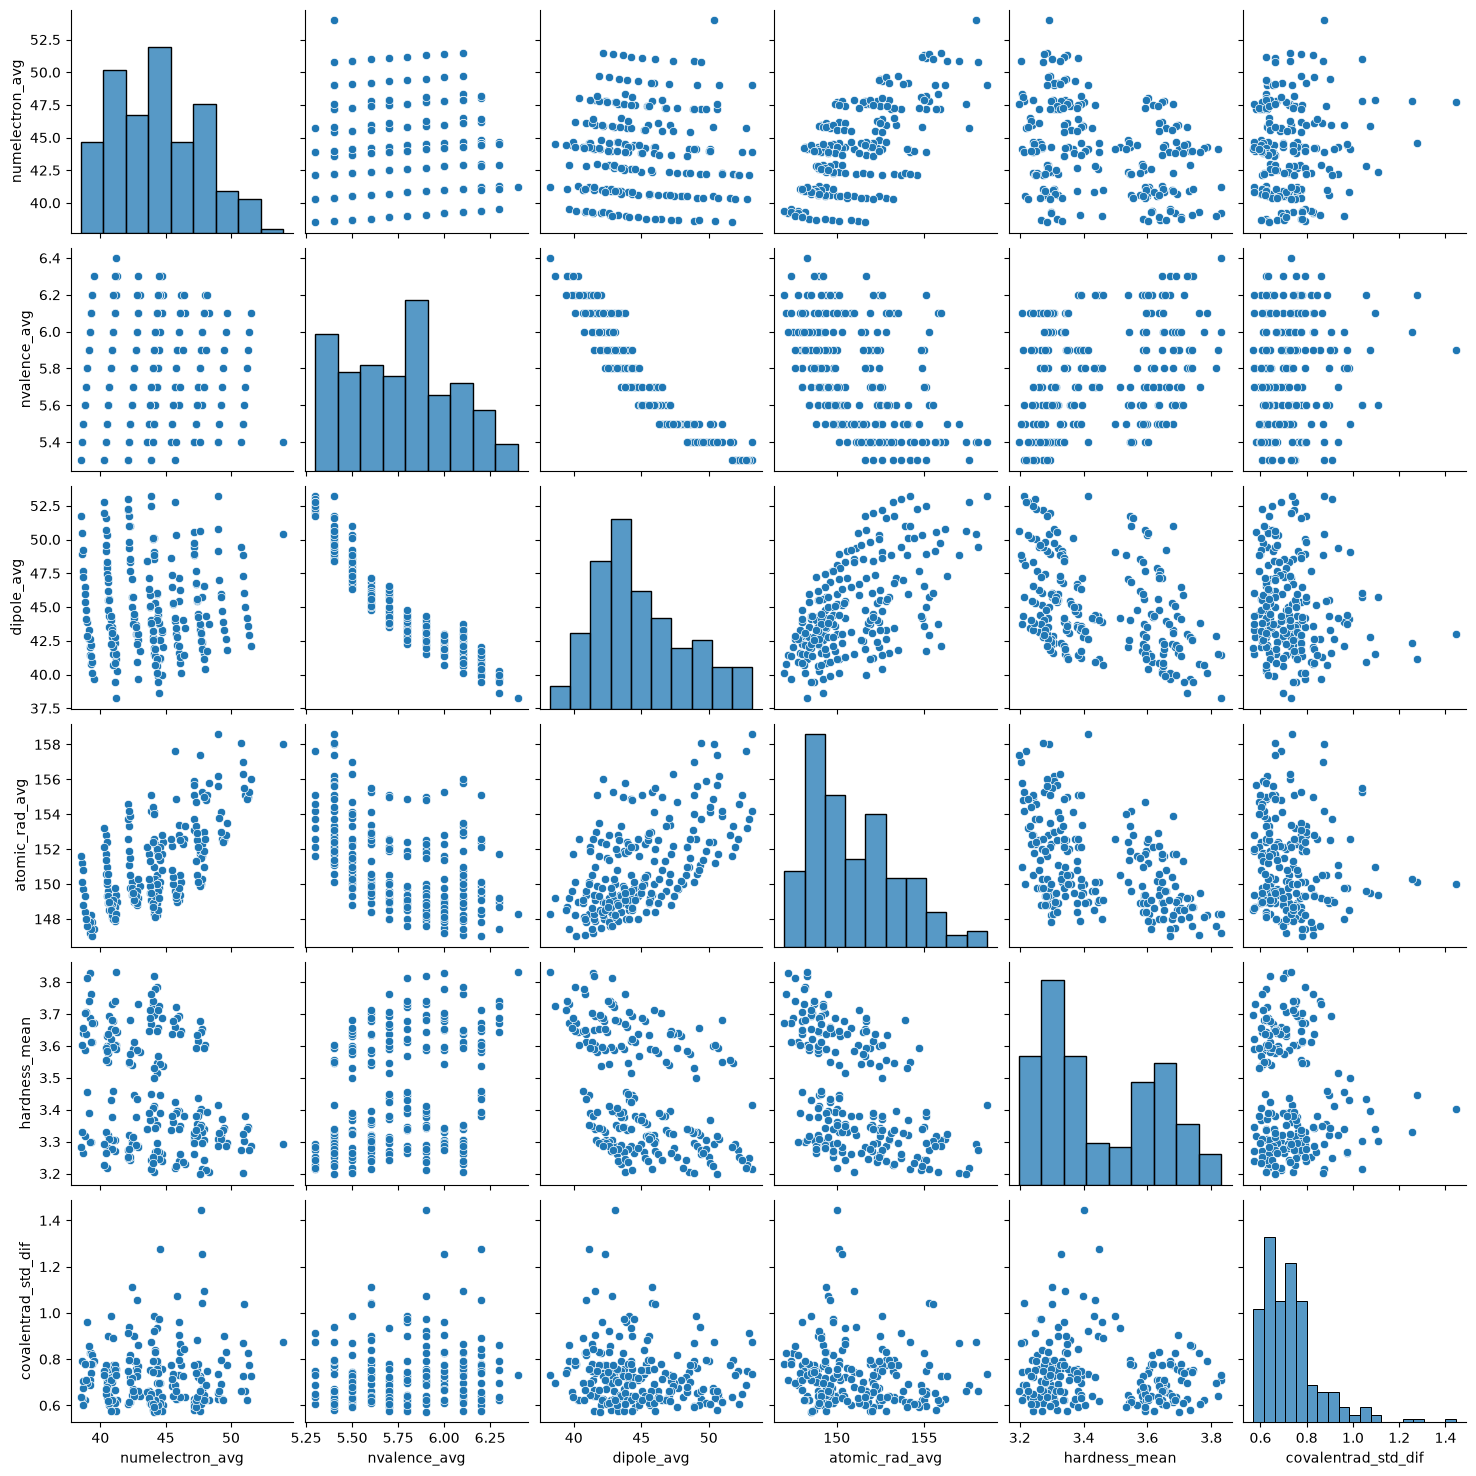

In [ ]:
sns.pairplot(X)
# what does sns.pairplot() do?

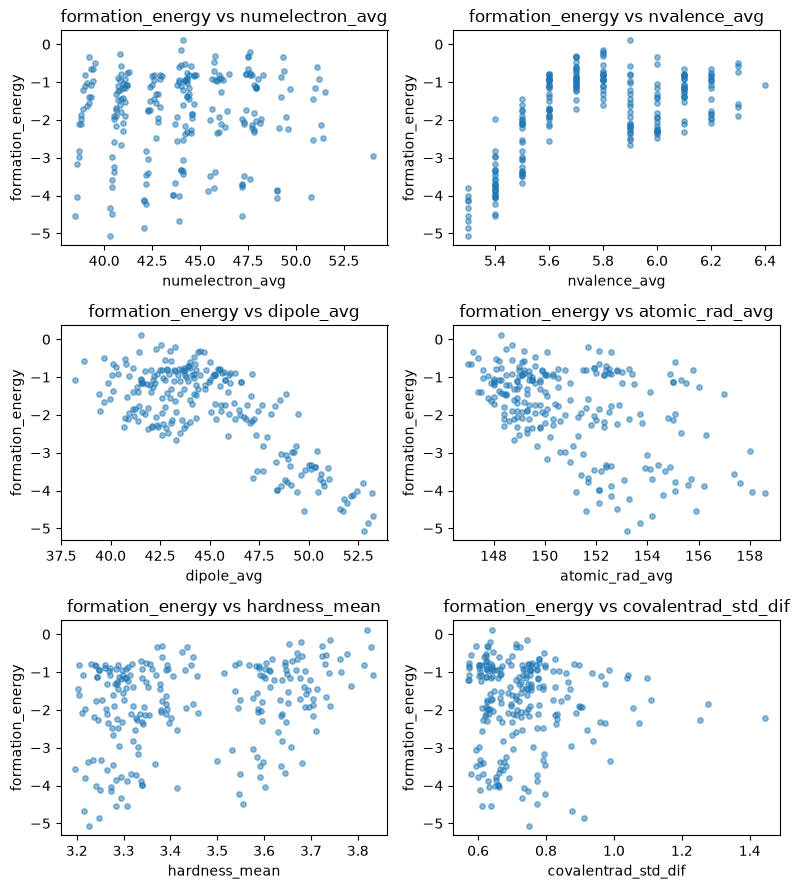

In [ ]:
import matplotlib.pyplot as plt
import math

# study this function which can help you to inspect your data
def scatter_grid(df, y_col, x_cols, ncols=3, figsize_per=(4, 3), alpha=0.5):
    """
    Scatter-plot y_col against each column in x_cols.

    df       : pandas DataFrame
    y_col    : str, name of the y variable
    x_cols   : list[str], subset of columns to plot on the x-axis
    ncols    : number of subplot columns in the grid
    """
    n = len(x_cols)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        squeeze=False,
    )
    axes = axes.flatten()

    for ax, x_col in zip(axes, x_cols):
        ax.scatter(df[x_col], df[y_col], alpha=alpha, s=15)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"{y_col} vs {x_col}")

    # hide any unused axes in the grid
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    return fig, axes

x_cols = X.columns[:6].tolist()
fig, axes = scatter_grid(df, y_col="formation_energy", x_cols=x_cols, ncols=2)
plt.show()

# What does the code above do? Modify it as needed to inspect other descriptors.

## More data munging/cleaning:
### Inspect and remove highly correlated descriptors

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ---------------------------------------------------------
# 1. Compute correlation matrix among features (absolute values)
# ---------------------------------------------------------
corr_matrix = X.corr().abs()

# ---------------------------------------------------------
# 2. Look only at the upper triangle to avoid duplicate pairs
#    and self-correlation (diagonal of 1.0)
# ---------------------------------------------------------
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# ---------------------------------------------------------
# 3. Find all pairs above a correlation threshold
# ---------------------------------------------------------
CORR_THRESHOLD = 0.90

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={'level_0':'feature_1', 'level_1':'feature_2', 0: 'correlation'})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'] > CORR_THRESHOLD]
high_corr_pairs = high_corr_pairs.sort_values('correlation', ascending=False)

print(f"Number of highly correlated pairs (> {CORR_THRESHOLD}): {len(high_corr_pairs)}")
print(high_corr_pairs.head(20))

# ---------------------------------------------------------
# 4. Compute each feature's correlation with the target label
# ---------------------------------------------------------
target_corr = X.corrwith(df['formation_energy']).abs()

print("\nTop 6 features by correlation with label:")
print(target_corr.sort_values(ascending=False).head(10))

# ---------------------------------------------------------
# 5. For each highly correlated pair, drop whichever feature
#    is LESS correlated with the target label
# ---------------------------------------------------------
cols_to_drop = set()
drop_log = []  # keep a record of decisions for transparency

for _, row in high_corr_pairs.iterrows():
    f1, f2 = row['feature_1'], row['feature_2']

    # skip if either feature already marked for removal
    if f1 in cols_to_drop or f2 in cols_to_drop:
        continue

    f1_target_corr = target_corr.get(f1, 0)
    f2_target_corr = target_corr.get(f2, 0)

    if f1_target_corr < f2_target_corr:
        dropped, kept = f1, f2
    else:
        dropped, kept = f2, f1

    cols_to_drop.add(dropped)
    drop_log.append({
        'dropped': dropped,
        'kept': kept,
        'pair_correlation': row['correlation'],
        'dropped_target_corr': target_corr.get(dropped, 0),
        'kept_target_corr': target_corr.get(kept, 0)
    })

cols_to_drop = list(cols_to_drop)
drop_log_df = pd.DataFrame(drop_log)

print(f"\nColumns to drop due to high correlation: {len(cols_to_drop)}")
print("\nSample of drop decisions:")
print(drop_log_df.head(10))

# ---------------------------------------------------------
# 6. Drop and inspect result
# ---------------------------------------------------------
df_decorrelated = X.drop(columns=cols_to_drop)

print(f"\nShape before correlation filtering: {X.shape}")
print(f"Shape after correlation filtering:  {df_decorrelated.shape}")


Number of highly correlated pairs (> 0.9): 1
      feature_1   feature_2  correlation
8  nvalence_avg  dipole_avg     0.934282

Top 10 features by correlation with label:
dipole_avg             0.738905
nvalence_avg           0.601653
atomic_rad_avg         0.480765
hardness_mean          0.271177
numelectron_avg        0.041116
covalentrad_std_dif    0.019876
dtype: float64

Columns to drop due to high correlation: 1

Sample of drop decisions:
        dropped        kept  pair_correlation  dropped_target_corr  \
0  nvalence_avg  dipole_avg          0.934282             0.601653   

   kept_target_corr  
0          0.738905  

Shape before correlation filtering: (226, 6)
Shape after correlation filtering:  (226, 5)


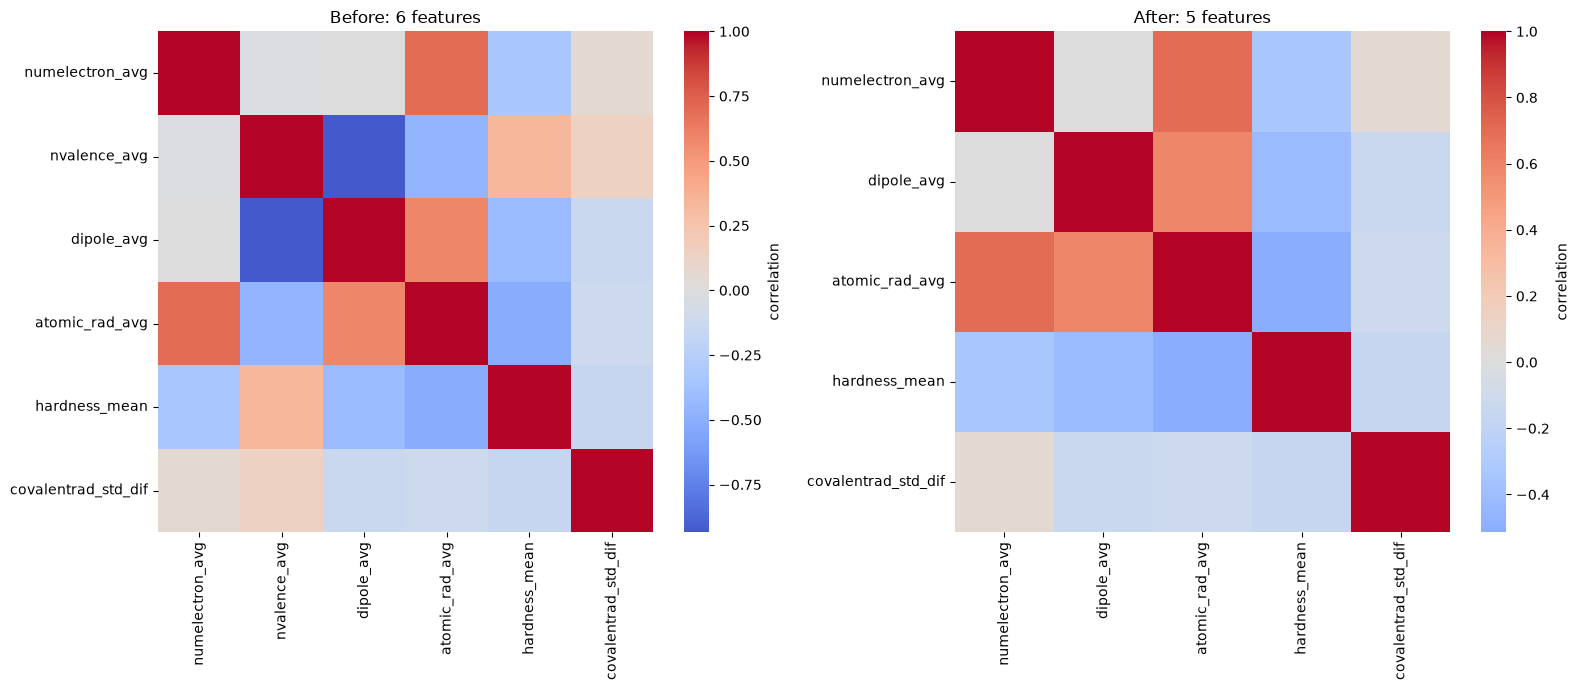


Remaining highly correlated pairs after filtering: 0


In [ ]:

# ---------------------------------------------------------
# 7. Visualize before/after correlation structure
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(X.corr(), cmap='coolwarm', center=0, ax=axes[0],
            cbar_kws={'label': 'correlation'})
axes[0].set_title(f'Before: {X.shape[1]} features')

remaining_cols = [c for c in df_decorrelated.columns if c not in ['label', 'timestamp']]
sns.heatmap(df_decorrelated[remaining_cols].corr(), cmap='coolwarm', center=0, ax=axes[1],
            cbar_kws={'label': 'correlation'})
axes[1].set_title(f'After: {len(remaining_cols)} features')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. Verify no highly correlated pairs remain
# ---------------------------------------------------------
remaining_corr = df_decorrelated[remaining_cols].corr().abs()
remaining_upper = remaining_corr.where(
    np.triu(np.ones(remaining_corr.shape), k=1).astype(bool)
)
remaining_high_corr = (remaining_upper > CORR_THRESHOLD).sum().sum()
print(f"\nRemaining highly correlated pairs after filtering: {remaining_high_corr}")

## Machine Learning
Learn a function, $f(X)$ that maps the descriptors, $X$ to the target value, $y$

### Random Forest Regression

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print(f"Feature matrix shape: {X.shape}")

# ---------------------------------------------------------
# 1. Train/validation/test split 
# ---------------------------------------------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=31415
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.10,
    random_state=31415
)

print(f"\nTrain shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
# Why do we need to create a validation set?

# ===========================
# Build Random Forest
# ===========================

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=3142,
    n_jobs=-1
)
# Note that n_estimators, max_depth, etc. are called the hyperparameters of the model

# ===========================
# Train
# ===========================

rf.fit(X_train, y_train)
# Why do we train the model on the training set only and not on the entire data set?

# ===========================
# Predict
# ===========================

y_pred_train = rf.predict(X_train)
y_pred_val = rf.predict(X_val)
y_pred_test = rf.predict(X_test)

Feature matrix shape: (226, 6)

Train shape: (182, 6), Val shape: (21, 6), Test shape: (23, 6)


Visualize the results of the predictions.
Use a parity plot to compare the predictions and the actual values.

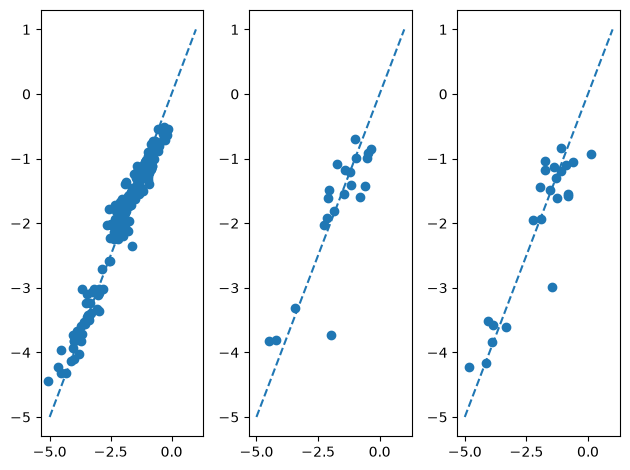

In [ ]:
plt.subplot(1,3,1)
plt.scatter(y_train, y_pred_train)
plt.plot([-5,1],[-5,1],'--')

plt.subplot(1,3,2)
plt.scatter(y_val, y_pred_val)
plt.plot([-5,1],[-5,1],'--')

plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_test)
plt.plot([-5,1],[-5,1],'--')

plt.tight_layout()

# add axis labels and a title for each panel

In [ ]:
# ===========================
# Metrics: How do we quantify the model performance?
# ===========================

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_val = mean_absolute_error(y_val, y_pred_val)
mae_test = mean_absolute_error(y_test, y_pred_test)
rms_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
# add the rms and r2 for the validation and training sets

print(f"MAE test : {mae_test:.4f}")
print(f"RMSE test: {rms_test:.4f}")
print(f"R² test : {r2_test:.4f}")



MAE test : 0.4203
RMSE test: 0.5564
R² test : 0.8220


What is a good MAE, RMSE, $R^2$ score?

### Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop Features:")
print(importance.head(20))


Top Features:
               Feature  Importance
2           dipole_avg    0.466368
1         nvalence_avg    0.261941
3       atomic_rad_avg    0.106642
4        hardness_mean    0.064644
0      numelectron_avg    0.053313
5  covalentrad_std_dif    0.047091


Consider the following:

- What are hyperparameters? What are the hyperparameters for the random forest model and how do they affect the model performance? 
See: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

- Manually change the hyperparameters. Can you improve the validation score? 

- What's the role of the training, validation and test scores?

- Earlier, we guessed that the following list of descriptors is useful: {'numelectron_avg', 'nvalence_avg', 'dipole_avg', 'atomic_rad_avg', 'hardness_mean', 'covalentrad_std_dif'}. Using the random forest feature analysis described above, can you think of some ways to investigate the usefulness of the other features in the data set.

## Challenge Questions:
- How can your machine learning model be used for materials discovery?

- How do you systematically tune the hyperparameters? Investigate the following:
    - Overfitting
    - Cross-validation
    - Hyperparameter tuning with GridSearchCV

- Repeat the model training and hyperparamter tuning for the 'magnetic_moment'.  Can you get a good result? Why might magnetic moment be harder to learn?

- Create your own features using matminer (or other more sophisticated tools, such as SOAP or CGCNN)

- In semiconductor manufacturing we are interested in predicting whether the wafer fabrication process 'failed' or 'passed'. That can be predicted using a classification model.  To get practice with a classification model, use the 2D materials data set in this notebook to predict 'spin_index', which describes whether the constituent spins are parallel (ferromagnetic) or anti-parallel.



In [1]:
# Write your code in the cells below. Use comments and markdown where appropriate.